# 📊 Customer Churn Prediction & Retention Strategy

## 🎯 Objective

This notebook focuses on identifying churn drivers,
segmenting customer risk,
and building a predictive framework to support retention strategies.

Main goals:
- Measure churn patterns
- Segment high-risk customers
- Identify behavioral predictors
- Build a simple churn prediction model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

sns.set_style("whitegrid")

BASE_URL = "https://raw.githubusercontent.com/gibiai/Customer_Churn_Analysis_Retention_Strategy-Subscription_Business_2025/main/dataset/"

# Loading cleaned dataset from Notebook 1
df = pd.read_csv(BASE_URL + "final_dataset.csv")

In [10]:
# Core business KPIs
churn_rate = df["churn"].mean()
avg_usage = df["total_usage"].mean()
avg_tickets = df["ticket_count"].mean()

print("Churn Rate:", round(churn_rate, 2))
print("Average Usage:", round(avg_usage, 2))
print("Average Support Tickets:", round(avg_tickets, 2))

Churn Rate: 0.7
Average Usage: 501.05
Average Support Tickets: 4.0


In [11]:
# Creating business-friendly customer risk segments
df["risk_segment"] = np.where(
    (df["inactive"] == 1) &
    (df["low_satisfaction"] == 1),
    "High Risk",
    "Low Risk"
)

In [12]:
# Reviewing churn by segment
pd.crosstab(df["risk_segment"], df["churn"], normalize="index")

churn,0,1
risk_segment,,
High Risk,0.313953,0.686047
Low Risk,0.292271,0.707729


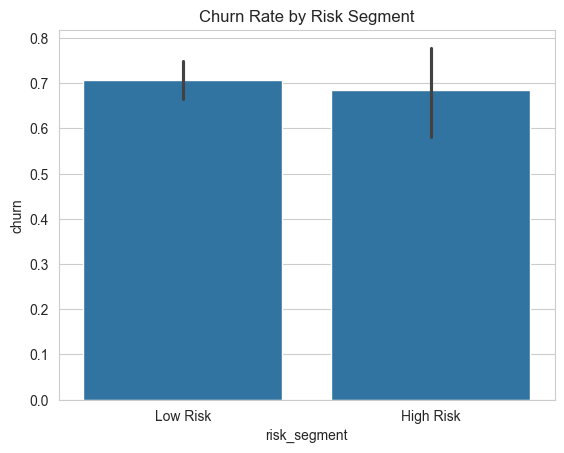

In [13]:
sns.barplot(x="risk_segment", y="churn", data=df)
plt.title("Churn Rate by Risk Segment")
plt.show()

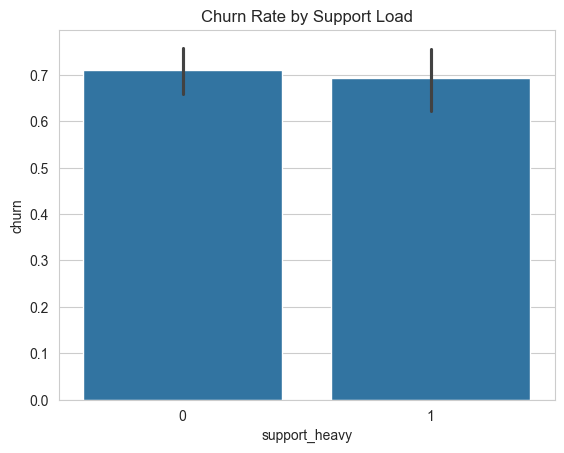

In [14]:
sns.barplot(x="support_heavy", y="churn", data=df)
plt.title("Churn Rate by Support Load")
plt.show()

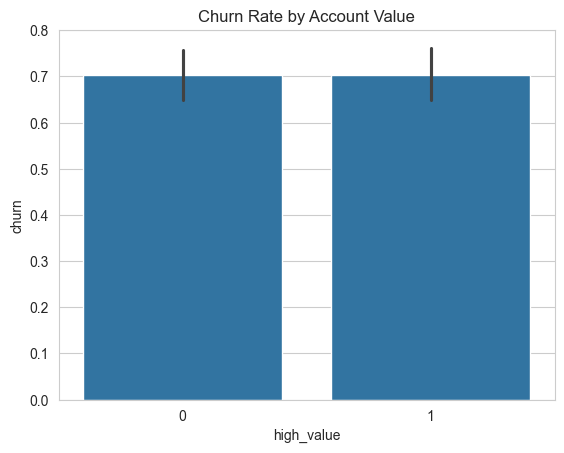

In [16]:
sns.barplot(x="high_value", y="churn", data=df)
plt.title("Churn Rate by Account Value")
plt.show()

In [17]:
# Identifying whether valuable customers are still at churn risk
pd.crosstab(
    [df["high_value"], df["risk_segment"]],
    df["churn"],
    normalize="index"
)

churn                           0         1
high_value risk_segment                    
0          High Risk     0.263158  0.736842
           Low Risk      0.301802  0.698198
1          High Risk     0.354167  0.645833
           Low Risk      0.281250  0.718750

In [18]:
# Selecting practical business predictors
X = df[[
    "total_usage",
    "seats",
    "ticket_count",
    "avg_satisfaction",
    "total_escalations"
]]

y = df["churn"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred = model.predict(X_test)

In [22]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("Precision:", round(precision_score(y_test, y_pred), 2))
print("Recall:", round(recall_score(y_test, y_pred), 2))

Accuracy: 0.67
Precision: 0.67
Recall: 1.0


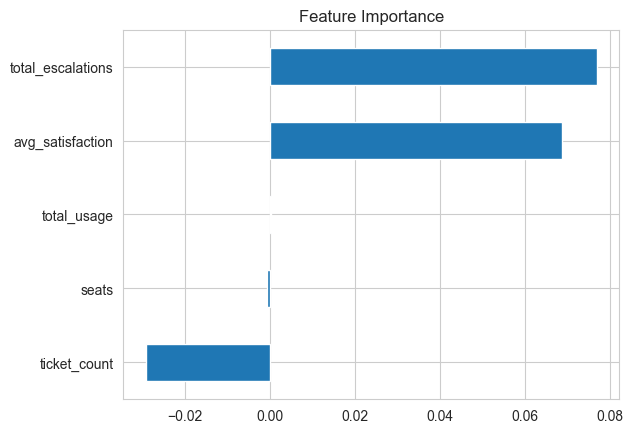

In [23]:
# Reviewing strongest churn predictors
importance = pd.Series(model.coef_[0], index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

## 📌 Final Business Insights

- Inactivity and customer dissatisfaction are primary churn drivers  
- High-value customers are still vulnerable when engagement declines  
- Support burden and escalations may indicate retention risk  
- Behavioral indicators outperform static account size  

## 🎯 Strategic Recommendation:
Prioritize proactive retention campaigns for:
- inactive accounts
- low satisfaction accounts
- high-value customers showing behavioral decline

In [24]:
# Saving enriched segmentation dataset for Power BI
df.to_csv("final_dataset_segmented.csv", index=False)